# Introduction
Here we provide code for benchmarking SeQuant embeddings. The comparison was carried out with common encoding methods - one-hot, blosum and threemers; additionaly we used the ProtBERT model embeddings

## Libs import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import cross_val_predict, StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.stats import sem
import scipy.stats as st

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor

## Variables
To obtain encoded data run "benchmark_data_preprocessing.py"

In [ ]:
classification_datasets = ['antimic', 'antidia', 'antiinf', 'antiox']
regression_datasets = ['Instability_Index', 'Theoretical_Net_Charge', 'Isoelectric_Point', 'Molecular_Weight']
encodings = ['one_hot', 'threemers', 'blosum62', 'protbert', 'sequant']
np.random.seed(42)

os.makedirs('models', exist_ok=True)
os.makedirs('splits', exist_ok=True)

## Classification task

In [ ]:
metrics_list = []

for dataset in classification_datasets:
  for encoding in encodings:

    print(f'Processing dataset: {dataset}, encoding: {encoding}')

    # Read data
    df = pd.read_csv(f'data/encoded/{dataset}_{encoding}.csv')

    # Scale descriptors
    descriptors = df.drop(columns=['seq', 'label'])

    scaler = MinMaxScaler()
    scaled_descriptors = scaler.fit_transform(descriptors)

    # Save scaler
    # joblib.dump(scaler, f"{task}_{encoding}_scaler.pkl")

    scaled_df = pd.DataFrame(scaled_descriptors, columns=descriptors.columns)
    scaled_df['seq'] = df['seq']
    scaled_df['label'] = df['label']

    # Prepare for cross-validation
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_metrics = []

    # Initialize the model
    model = GradientBoostingClassifier(random_state=42)

    # Define descriptors and label
    X = scaled_df.drop(columns=['seq', 'label'])
    y = scaled_df['label']

    # Training
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
      # Split data on training and test datasets
      X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
      y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

      # Train model
      model.fit(X_train, y_train)

      if encoding == 'sequant':
        # Saving model for current fold for further analysis
        model_filename = f'models/{dataset}_{encoding}_fold{fold_idx + 1}.pkl'
        joblib.dump(model, model_filename)
        print(f'Model saved: {model_filename}')

        # Save test indices for this fold
        split_filename = f'splits/{dataset}_{encoding}_fold{fold_idx + 1}_test_indices.txt'
        np.savetxt(split_filename, test_idx, fmt='%d')
        print(f'Test indices saved: {split_filename}')

      # Inference
      y_pred_test = model.predict(X_test)

      # Evaluate metrics
      accuracy = accuracy_score(y_test, y_pred_test)
      precision = precision_score(y_test, y_pred_test)
      recall = recall_score(y_test, y_pred_test)
      f1 = f1_score(y_test, y_pred_test)
      roc_auc = roc_auc_score(y_test, y_pred_test)
      mcc = matthews_corrcoef(y_test, y_pred_test)

      tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

      # Save current split result
      cv_metrics.append({
          'accuracy': accuracy,
          'precision': precision,
          'recall': recall,
          'f1_score': f1,
          'roc_auc': roc_auc,
          'mcc': mcc,
          'tn': tn,
          'fp': fp,
          'fn': fn,
          'tp': tp
      })

    # Calculate mean and std error
    mean_metrics = {metric: np.mean([fold[metric] for fold in cv_metrics]) for metric in cv_metrics[0].keys()}
    std_err_metrics = {metric: sem([fold[metric] for fold in cv_metrics]) for metric in cv_metrics[0].keys()}

    # Add results
    metrics_list.append({
        'task': dataset,
        'encoding_strategy': encoding,
        **{f'mean_{metric}': mean_metrics[metric] for metric in mean_metrics.keys()},
        **{f'std_err_{metric}': std_err_metrics[metric] for metric in std_err_metrics.keys()}
    })

    print(f'Results for dataset: {dataset}, encoding: {encoding}')
    for metric in mean_metrics.keys():
        print(f'  {metric}: {mean_metrics[metric]:.4f} ± {std_err_metrics[metric]:.4f}')

metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv('classification_metrics_5_fold.csv', index=False)

Processing dataset: antimic, encoding: one_hot
Results for dataset: antimic, encoding: one_hot
  accuracy: 0.7785 ± 0.0015
  precision: 0.8093 ± 0.0011
  recall: 0.7288 ± 0.0048
  f1_score: 0.7669 ± 0.0023
  roc_auc: 0.7785 ± 0.0015
  mcc: 0.5599 ± 0.0026
  tn: 684.8000 ± 1.9339
  fp: 142.0000 ± 1.7889
  fn: 224.2000 ± 3.9547
  tp: 602.6000 ± 3.8807
Processing dataset: antimic, encoding: threemers
Results for dataset: antimic, encoding: threemers
  accuracy: 0.7589 ± 0.0012
  precision: 0.7772 ± 0.0024
  recall: 0.7262 ± 0.0024
  f1_score: 0.7508 ± 0.0012
  roc_auc: 0.7589 ± 0.0012
  mcc: 0.5190 ± 0.0026
  tn: 654.6000 ± 2.8740
  fp: 172.2000 ± 2.7459
  fn: 226.4000 ± 1.9647
  tp: 600.4000 ± 1.9647
Processing dataset: antimic, encoding: blosum62
Results for dataset: antimic, encoding: blosum62
  accuracy: 0.6668 ± 0.0073
  precision: 0.6926 ± 0.0100
  recall: 0.6006 ± 0.0066
  f1_score: 0.6432 ± 0.0069
  roc_auc: 0.6668 ± 0.0073
  mcc: 0.3367 ± 0.0150
  tn: 606.0000 ± 9.8031
  fp: 220.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Results for dataset: antimic, encoding: protbert
  accuracy: 0.4999 ± 0.0001
  precision: 0.3999 ± 0.1000
  recall: 0.8000 ± 0.2000
  f1_score: 0.5333 ± 0.1333
  roc_auc: 0.5000 ± 0.0000
  mcc: 0.0000 ± 0.0000
  tn: 165.2000 ± 165.2000
  fp: 661.6000 ± 165.4000
  fn: 165.4000 ± 165.4000
  tp: 661.4000 ± 165.3501
Processing dataset: antimic, encoding: sequant
Model saved: models/antimic_sequant_fold1.pkl
Test indices saved: splits/antimic_sequant_fold1_test_indices.txt
Model saved: models/antimic_sequant_fold2.pkl
Test indices saved: splits/antimic_sequant_fold2_test_indices.txt
Model saved: models/antimic_sequant_fold3.pkl
Test indices saved: splits/antimic_sequant_fold3_test_indices.txt
Model saved: models/antimic_sequant_fold4.pkl
Test indices saved: splits/antimic_sequant_fold4_test_indices.txt
Model saved: models/antimic_sequant_fold5.pkl
Test indices saved: splits/antimic_sequant_fold5_test_indices.txt
Results for dataset: antimic, encoding: sequant
  accuracy: 0.7094 ± 0.0068
  p

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Results for dataset: antidia, encoding: protbert
  accuracy: 0.4979 ± 0.0013
  precision: 0.3989 ± 0.0997
  recall: 0.8000 ± 0.2000
  f1_score: 0.5324 ± 0.1331
  roc_auc: 0.5000 ± 0.0000
  mcc: 0.0000 ± 0.0000
  tn: 9.4000 ± 9.4000
  fp: 37.8000 ± 9.4520
  fn: 9.6000 ± 9.6000
  tp: 37.6000 ± 9.4000
Processing dataset: antidia, encoding: sequant
Model saved: models/antidia_sequant_fold1.pkl
Test indices saved: splits/antidia_sequant_fold1_test_indices.txt
Model saved: models/antidia_sequant_fold2.pkl
Test indices saved: splits/antidia_sequant_fold2_test_indices.txt
Model saved: models/antidia_sequant_fold3.pkl
Test indices saved: splits/antidia_sequant_fold3_test_indices.txt
Model saved: models/antidia_sequant_fold4.pkl
Test indices saved: splits/antidia_sequant_fold4_test_indices.txt
Model saved: models/antidia_sequant_fold5.pkl
Test indices saved: splits/antidia_sequant_fold5_test_indices.txt
Results for dataset: antidia, encoding: sequant
  accuracy: 0.5679 ± 0.0197
  precision: 0.56

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

Results for dataset: antiinf, encoding: protbert
  accuracy: 0.6172 ± 0.0003
  precision: 0.0000 ± 0.0000
  recall: 0.0000 ± 0.0000
  f1_score: 0.0000 ± 0.0000
  roc_auc: 0.5000 ± 0.0000
  mcc: 0.0000 ± 0.0000
  tn: 467.8000 ± 0.2000
  fp: 0.0000 ± 0.0000
  fn: 290.2000 ± 0.2000
  tp: 0.0000 ± 0.0000
Processing dataset: antiinf, encoding: sequant
Model saved: models/antiinf_sequant_fold1.pkl
Test indices saved: splits/antiinf_sequant_fold1_test_indices.txt
Model saved: models/antiinf_sequant_fold2.pkl
Test indices saved: splits/antiinf_sequant_fold2_test_indices.txt
Model saved: models/antiinf_sequant_fold3.pkl
Test indices saved: splits/antiinf_sequant_fold3_test_indices.txt
Model saved: models/antiinf_sequant_fold4.pkl
Test indices saved: splits/antiinf_sequant_fold4_test_indices.txt
Model saved: models/antiinf_sequant_fold5.pkl
Test indices saved: splits/antiinf_sequant_fold5_test_indices.txt
Results for dataset: antiinf, encoding: sequant
  accuracy: 0.6941 ± 0.0116
  precision: 0.

## Regression task

In [ ]:
metrics_list = []
for dataset in regression_datasets:
    for encoding in encodings:

        print(f'Processing dataset: {dataset}, encoding: {encoding}')

        # Read data
        df = pd.read_csv(f'data/encoded/{dataset}_{encoding}.csv')

        # Scale descriptors
        descriptors = df.drop(columns=['seq', 'target'])

        scaler = MinMaxScaler()
        scaled_descriptors = scaler.fit_transform(descriptors)

        # Save scaler
        # joblib.dump(scaler, f"{dataset}_{encoding}_scaler.pkl")

        scaled_df = pd.DataFrame(scaled_descriptors, columns=descriptors.columns)
        scaled_df['seq'] = df['seq']
        scaled_df['target'] = df['target']

        # Prepare for cross-validation
        n_splits = 5
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

        cv_metrics = []

        # Initialize the model
        model = XGBRegressor(random_state=42)

        # Define descriptors and label
        X = scaled_df.drop(columns=['seq', 'target'])
        y = scaled_df['target']

        # Training
        for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
            # Split data on training and test datasets
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Train model
            model.fit(X_train, y_train)

            if encoding == 'sequant':
              # Saving model for current fold for further analysis
              model_filename = f'models/{dataset}_{encoding}_fold{fold_idx + 1}.pkl'
              joblib.dump(model, model_filename)
              print(f'Model saved: {model_filename}')

              # Save test indices for this fold
              split_filename = f'splits/{dataset}_{encoding}_fold{fold_idx + 1}_test_indices.txt'
              np.savetxt(split_filename, test_idx, fmt='%d')
              print(f'Test indices saved: {split_filename}')

            # Inference
            y_pred_test = model.predict(X_test)

            # Evaluate metrics
            mae = mean_absolute_error(y_test, y_pred_test)
            mse = mean_squared_error(y_test, y_pred_test)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred_test)

            # Save current split result
            cv_metrics.append({
                'mae': mae,
                'mse': mse,
                'rmse': rmse,
                'r2': r2
            })

        # Calculate mean and std error for each metric
        mean_metrics = {metric: np.mean([fold[metric] for fold in cv_metrics]) for metric in cv_metrics[0].keys()}
        std_err_metrics = {metric: sem([fold[metric] for fold in cv_metrics]) for metric in cv_metrics[0].keys()}

        # Add results to metrics_list
        metrics_list.append({
            'task': dataset,
            'encoding_strategy': encoding,
            **{f'mean_{metric}': mean_metrics[metric] for metric in mean_metrics.keys()},
            **{f'std_err_{metric}': std_err_metrics[metric] for metric in std_err_metrics.keys()}
        })

        print(f'Results for dataset: {dataset}, encoding: {encoding}')
        for metric in mean_metrics.keys():
            print(f'  {metric}: {mean_metrics[metric]:.4f} ± {std_err_metrics[metric]:.4f}')

# Save results to a CSV file
metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv('regression_metrics_5_fold.csv', index=False)

Processing dataset: Instability_Index, encoding: protbert
Results for dataset: Instability_Index, encoding: protbert
  mae: 16.4059 ± 0.0594
  mse: 509.8015 ± 4.4719
  rmse: 22.5779 ± 0.0991
  r2: 0.3745 ± 0.0073
Processing dataset: Theoretical_Net_Charge, encoding: protbert
Results for dataset: Theoretical_Net_Charge, encoding: protbert
  mae: 1.1319 ± 0.0050
  mse: 2.9992 ± 0.1124
  rmse: 1.7306 ± 0.0323
  r2: 0.8485 ± 0.0043
Processing dataset: Isoelectric_Point, encoding: protbert
Results for dataset: Isoelectric_Point, encoding: protbert
  mae: 0.9301 ± 0.0027
  mse: 1.5152 ± 0.0077
  rmse: 1.2309 ± 0.0031
  r2: 0.8088 ± 0.0009
Processing dataset: Molecular_Weight, encoding: protbert
Results for dataset: Molecular_Weight, encoding: protbert
  mae: 552.0709 ± 1.0580
  mse: 582734.6302 ± 3013.7268
  rmse: 763.3603 ± 1.9791
  r2: 0.9322 ± 0.0004


## Metrics visualisation

In [ ]:
metrics_classification = pd.read_csv('classification_metrics_5_fold.csv')
metrics_classification

,task,encoding_strategy,mean_accuracy,mean_precision,mean_recall,mean_f1_score,mean_roc_auc,mean_mcc,mean_tn,mean_fp,...,std_err_accuracy,std_err_precision,std_err_recall,std_err_f1_score,std_err_roc_auc,std_err_mcc,std_err_tn,std_err_fp,std_err_fn,std_err_tp
0,antimic,one_hot,0.778664,0.809900,0.728351,0.766922,0.778664,0.560221,685.4,141.4,...,0.002045,0.002979,0.004157,0.002435,0.002046,0.004061,3.124100,2.993326,3.443835,3.426368
1,antimic,threemers,0.758950,0.777310,0.725931,0.750717,0.758949,0.519064,654.8,172.0,...,0.001236,0.002500,0.002432,0.001159,0.001237,0.002565,2.956349,2.828427,2.014944,2.009975
2,antimic,blosum62,0.666785,0.692625,0.600627,0.643224,0.666787,0.336690,606.0,220.8,...,0.007333,0.010000,0.006617,0.006870,0.007340,0.015041,9.803061,9.820387,5.453439,5.500909
3,antimic,protbert,0.499879,0.399940,0.800000,0.533280,0.500000,0.000000,165.2,661.6,...,0.000074,0.099985,0.200000,0.133320,0.000000,0.000000,165.200000,165.400000,165.400000,165.350113
4,antimic,sequant,0.783381,0.806656,0.746014,0.774930,0.783382,0.568643,678.6,148.2,...,0.001068,0.005746,0.007435,0.001642,0.001066,0.002488,7.046985,6.916647,6.180615,6.044833
5,antidia,one_hot,0.597514,0.596308,0.622340,0.606079,0.597163,0.196519,27.0,20.2,...,0.008108,0.011850,0.032876,0.008670,0.008460,0.015169,2.280351,2.267157,1.496663,1.691153
6,antidia,threemers,0.559351,0.558954,0.558865,0.557619,0.559087,0.118514,26.4,20.8,...,0.029954,0.030937,0.040951,0.034052,0.029981,0.060156,1.805547,1.800000,1.881489,2.014944
7,antidia,blosum62,0.512721,0.511178,0.559752,0.532980,0.512766,0.025923,22.0,25.2,...,0.009822,0.008021,0.032057,0.017587,0.009775,0.019699,1.303840,1.157584,1.593738,1.435270
8,antidia,protbert,0.497895,0.398947,0.800000,0.532394,0.500000,0.000000,9.4,37.8,...,0.001289,0.099742,0.200000,0.133102,0.000000,0.000000,9.400000,9.451984,9.600000,9.400000
9,antidia,sequant,0.637872,0.637683,0.652482,0.642749,0.637589,0.277125,29.4,17.8,...,0.032113,0.033753,0.038520,0.030712,0.032256,0.064683,2.461707,2.416609,1.805547,1.827567


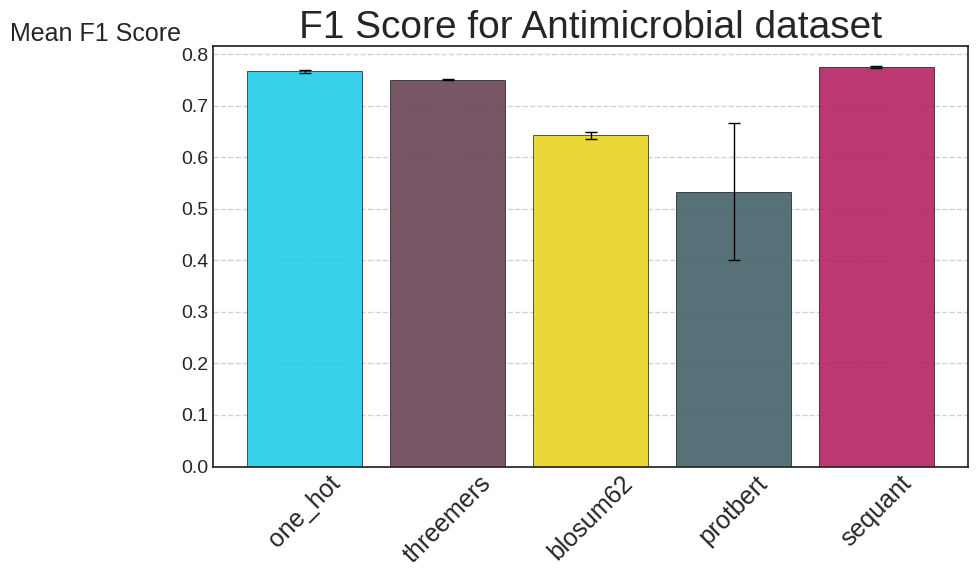

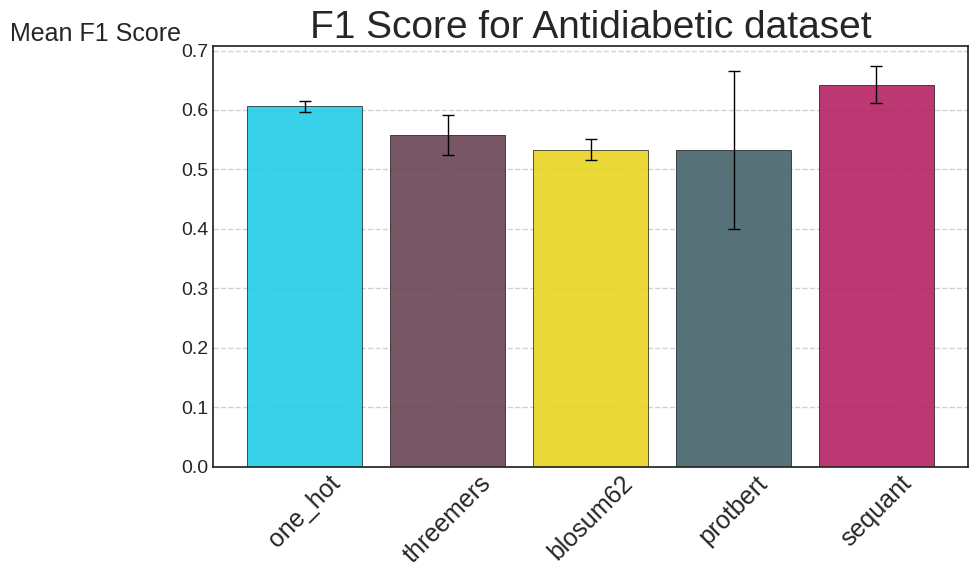

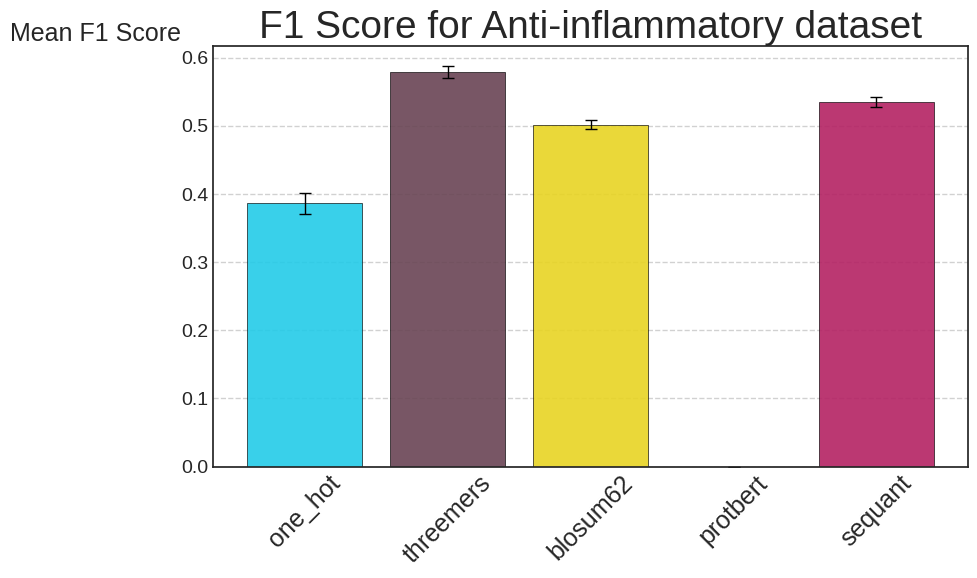

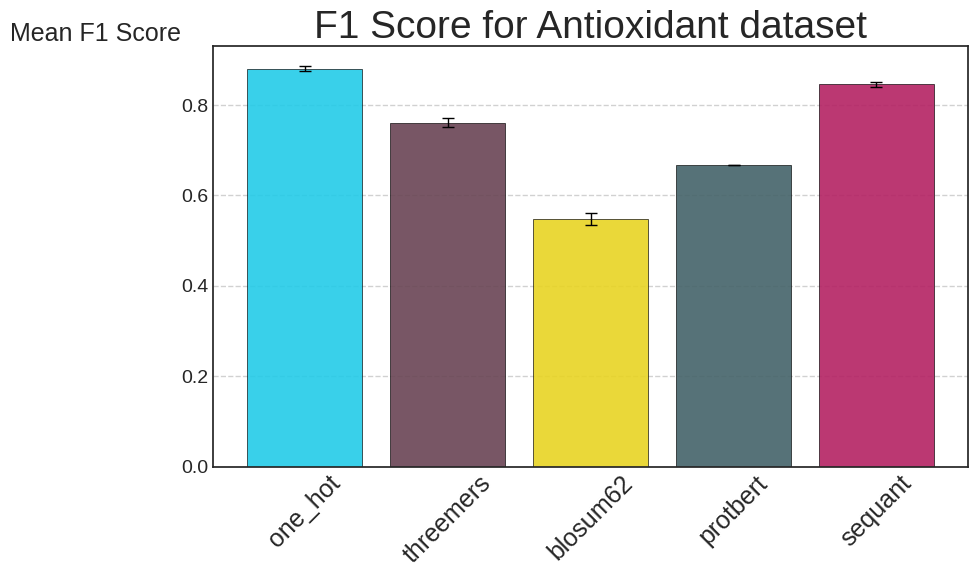

In [ ]:
# Unique tasks and encodings
tasks = metrics_classification['task'].unique()
encoding_strategies = metrics_classification['encoding_strategy'].unique()

# Style settings
plt.style.use('seaborn-v0_8-white')
colors = ['#23CBE8', '#694454', '#E8D423', '#446369', '#B42263']

for task in tasks:

    task_data = metrics_classification[metrics_classification['task'] == task]

    # Get metrics values
    mean_f1_scores = task_data['mean_f1_score']
    std_err_f1_scores = task_data['std_err_f1_score']

    x_positions = np.arange(len(encoding_strategies))

    plt.figure(figsize=(10, 6))
    plt.bar(x_positions, mean_f1_scores, yerr=std_err_f1_scores, color=colors, alpha=0.9, capsize=4, error_kw={'elinewidth': 1}, edgecolor='black')

    plt.xticks(x_positions, encoding_strategies, rotation=45, fontsize=18)
    plt.ylabel('Mean F1 Score', rotation=0, labelpad=0, fontsize=18, loc='top')

    if task == 'antimic':
      plt.title(f'F1 Score for Antimicrobial dataset', fontsize=28)
    elif task == 'antidia':
      plt.title(f'F1 Score for Antidiabetic dataset', fontsize=28)
    elif task == 'antiinf':
      plt.title(f'F1 Score for Anti-inflammatory dataset', fontsize=28)
    else:
      plt.title(f'F1 Score for Antioxidant dataset', fontsize=28)

    plt.grid(axis='y', linestyle='--', alpha=0.9)

    plt.tight_layout()
    plt.show()

# Latent space visualization

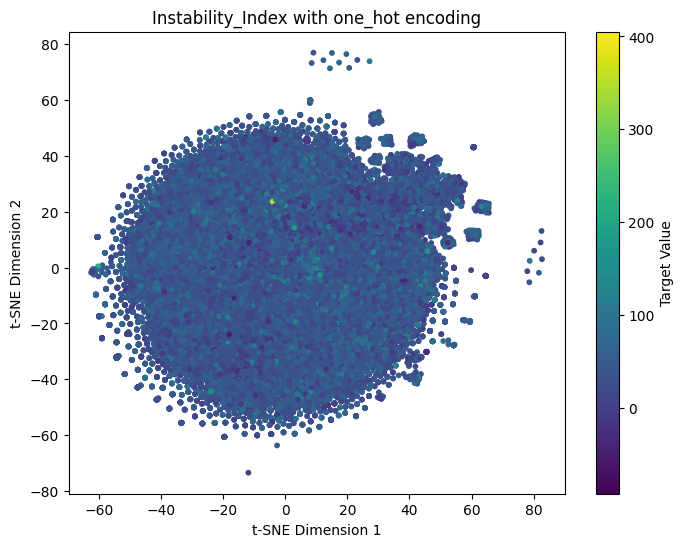

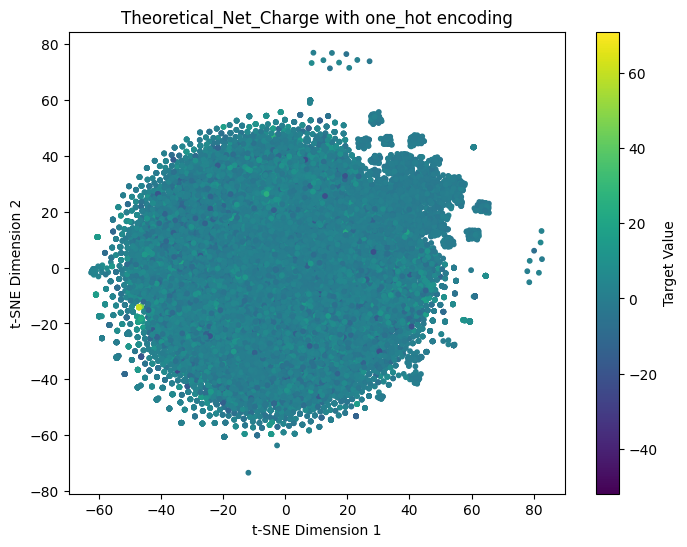

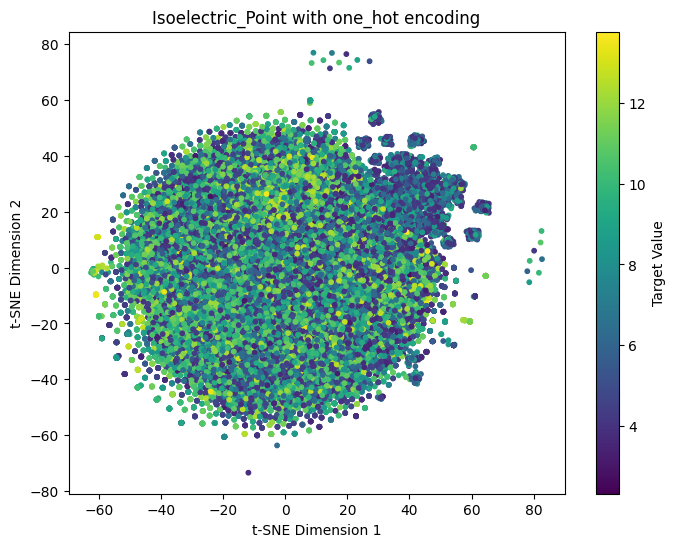

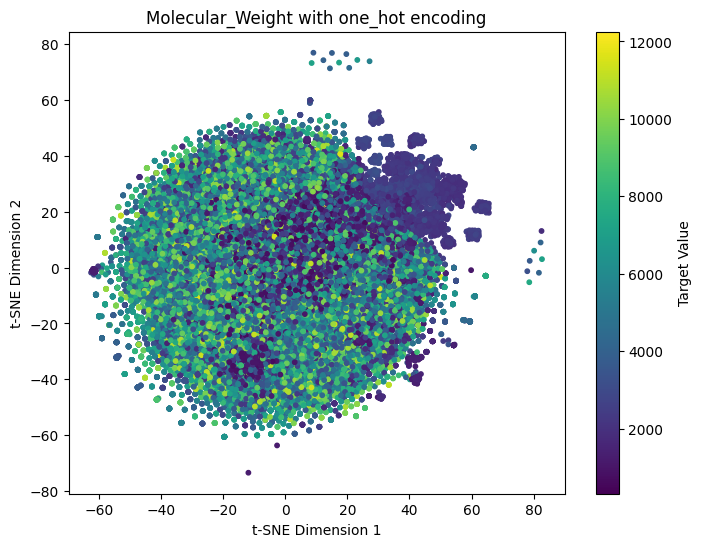

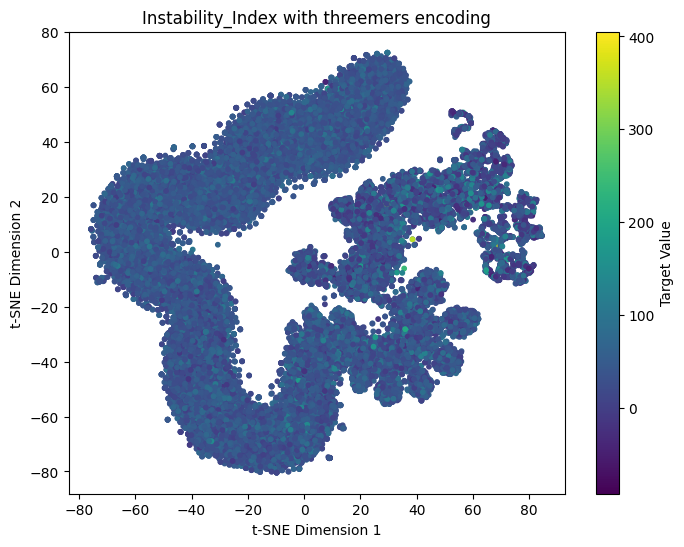

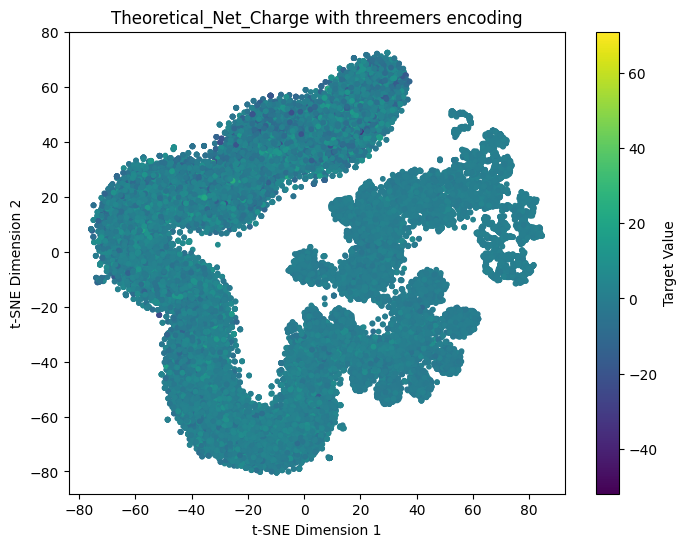

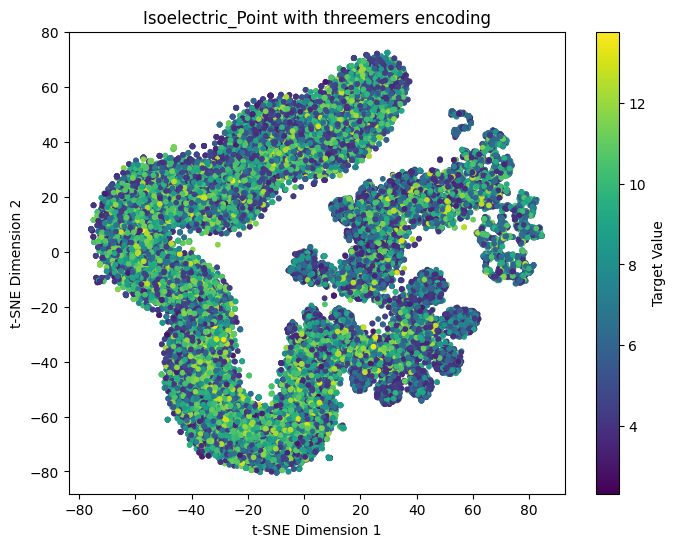

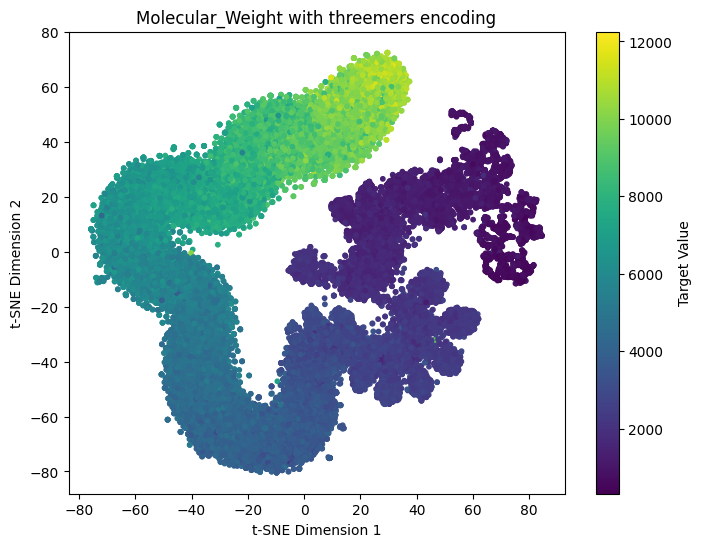

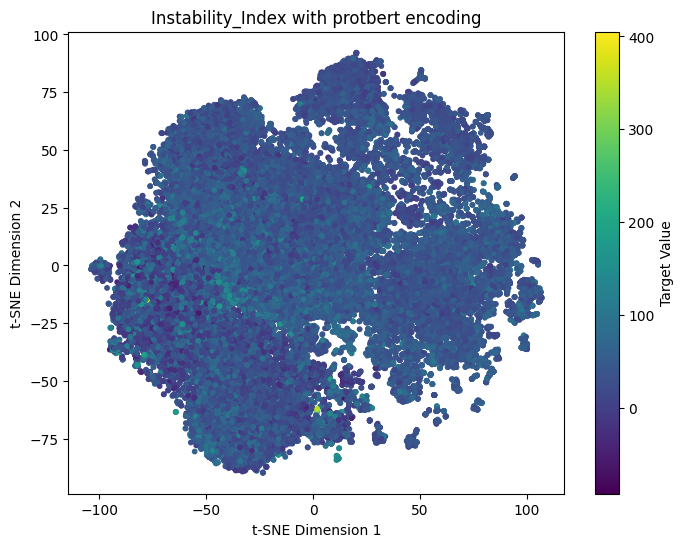

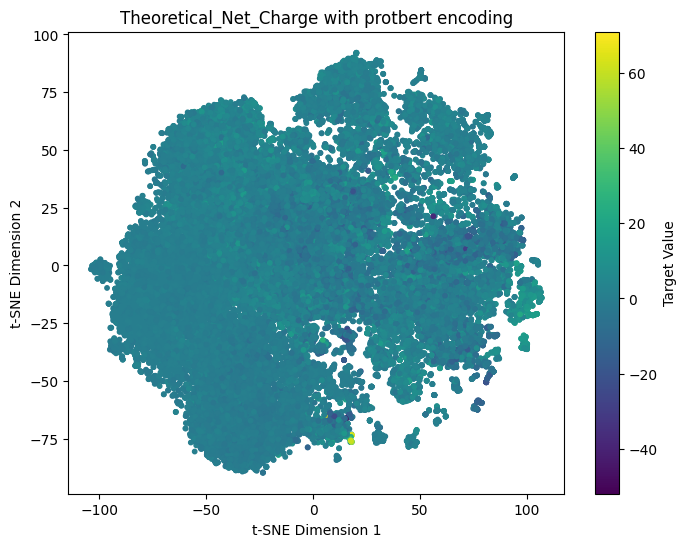

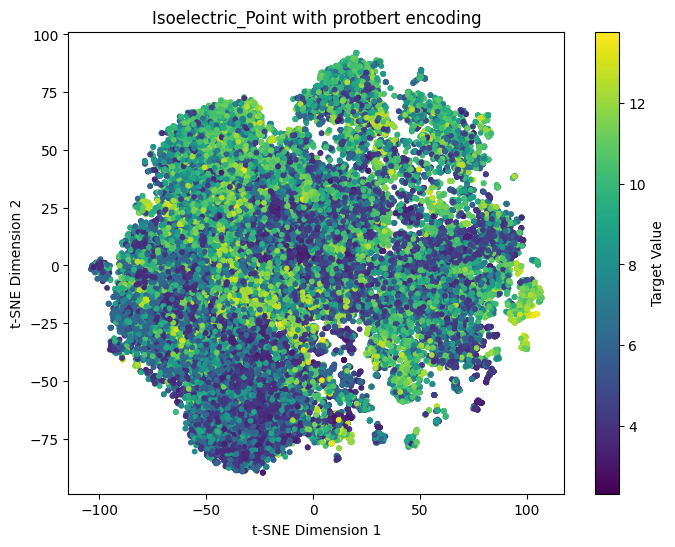

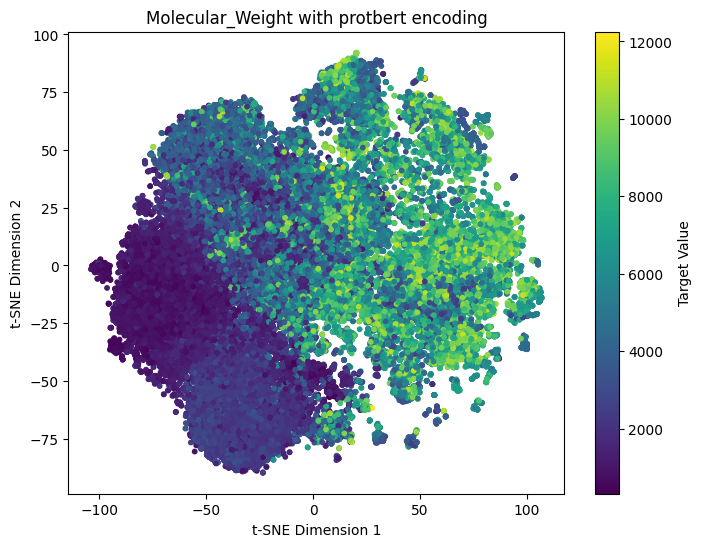

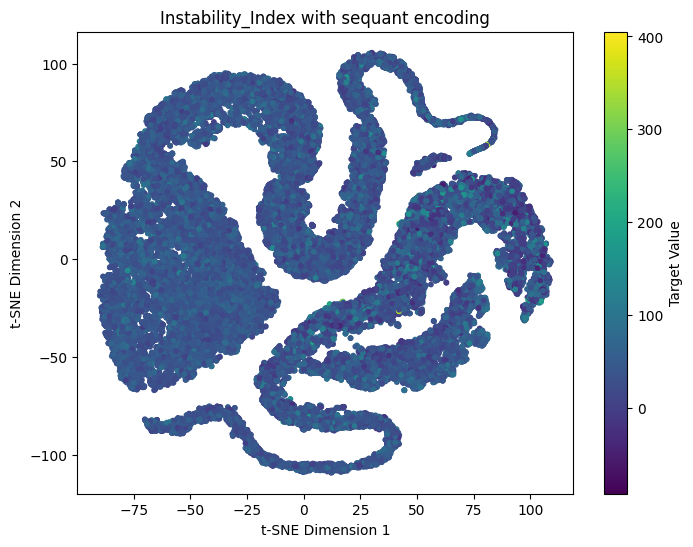

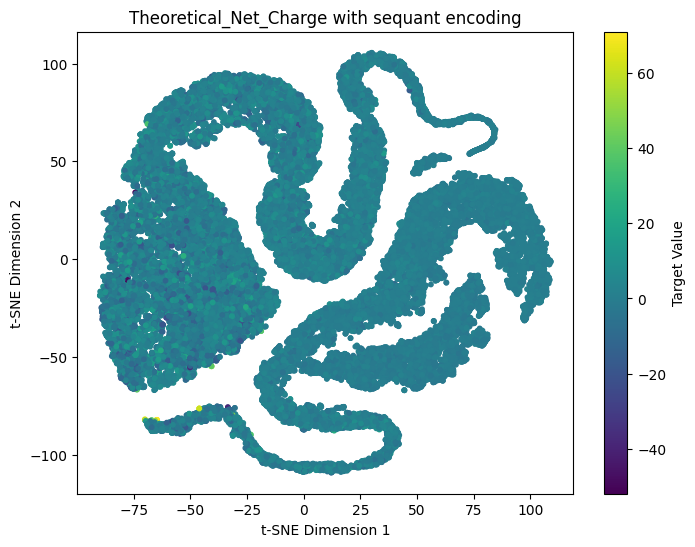

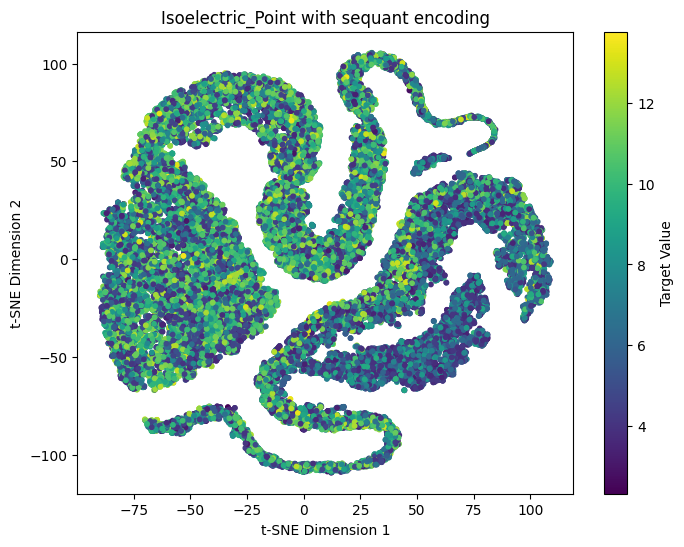

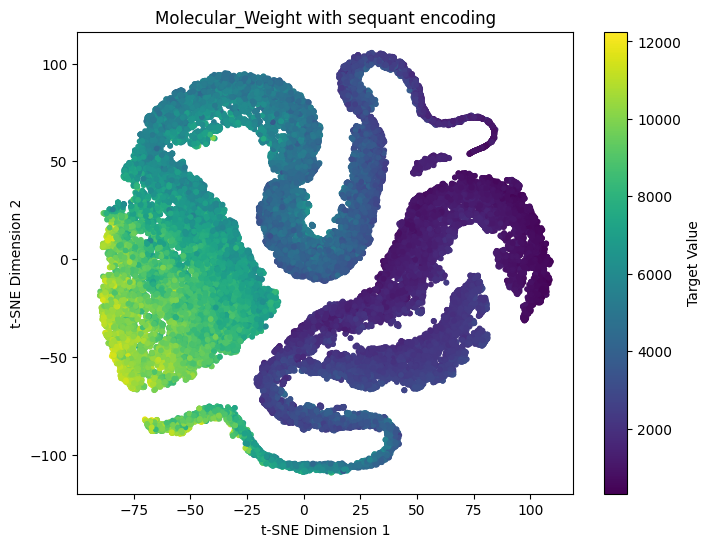

In [ ]:
encodings = ['one_hot', 'threemers', 'protbert', 'sequant']
def plot_tsne_with_target(df, title):
    X = df.drop(columns=['seq','target'])
    y = df['target']

    tsne = TSNE(n_components=2, random_state=42)
    X_embedded = tsne.fit_transform(X)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap='viridis', s=10)
    plt.colorbar(scatter, label='Target Value')
    plt.title(title)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.show()

for encoding in encodings:
    for dataset in regression_datasets:
        df = pd.read_csv(f'data/encoded/{dataset}_{encoding}.csv')

        if 'target' not in df.columns:
            print(f"Column 'target' not found")
            continue

        title = f"{dataset} with {encoding} encoding"
        plot_tsne_with_target(df, title)
